In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, kurtosis, skew

In [154]:
df = pd.read_csv("../data/raw/Star_Classification.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

I dati consistono in 100.000 osservazioni dello spazio effettuate dallo SDSS (Sloan Digital Sky Survey). Ogni osservazione è descritta da 17 colonne di caratteristiche e 1 colonna di classe che la identifica come stella, galassia o quasar. Il dataset non presenta `NULL`, si puo quindi procedere con l'EDA.

# Target 
### class

Vogliamo dare un'occhiata alla distribuzioni delle classi della variabile target

class
GALAXY    0.59445
STAR      0.21594
QSO       0.18961
Name: count, dtype: float64


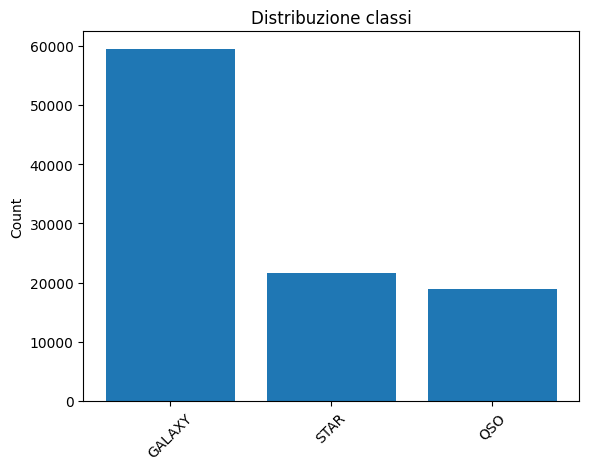

In [32]:
counts_targer = df["class"].value_counts()
print(df["class"].value_counts() / len(df))

plt.bar(counts_targer.index, counts_targer.values)

plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Distribuzione classi")
plt.savefig("../reports/figures/target_distr.png", dpi=200)
plt.show()

sono presenti 3 classi: Galaxy, Star e Quasar. La classe maggioritaria è Galaxy con il 59.4% della rappresentanza, e a seguire ci sono Star e Quasar, con il 21.6% e 19.0% rispettivamente. Ne concludiamo che il dataset è sbilanciato e dovremo applicare tecniche appropriate (come oversampling o peso delle classi) durante la fase di costruzione del modello.

# Features
## Variabili Categoriche
### obj_ID
Voglio verificare se gli ID degli oggetti siano unici

In [33]:
n_duplicate_ids = (df["obj_ID"].value_counts() > 1).sum()
print(f"numero di obj_ID distinti che appaiono più di una volta: {n_duplicate_ids}")

numero di obj_ID distinti che appaiono più di una volta: 15742


Facciamo un sanity check per valutare se record con `obj_ID` duplicato siano appartenenti alla stessa classe, magari sono osservazioni dello stesso oggetto in momenti e condizioni diverse, oppure no

In [34]:
df[df["obj_ID"].duplicated(keep=False)].groupby("obj_ID")["class"].nunique().value_counts()

class
1    9987
2    5303
3     452
Name: count, dtype: int64

L'analisi mostra che:

* un ampio sottoinsieme di ID oggetto corrisponde a una singola classe (etichettatura coerente)
* tuttavia, un sottoinsieme non trascurabile presenta più etichette di classe per lo stesso ID oggetto.

Questo indica che il dataset non è strettamente coerente a livello di etichetta a livello di oggetto, suggerendo la presenza di rumore nelle etichette o di annotazioni multiple a livello di osservazione.

Data questa struttura, procediamo trattando ogni riga come un'osservazione indipendente e ci affidiamo a modelli robusti al rumore nelle etichette. La caratteristica `obj_ID` viene esclusa dall'addestramento del modello in quanto rappresenta un identificatore univoco piuttosto che una caratteristica predittiva informativa.

### run_ID

Questa feature identifica la scansione del cielo ed implica:
* condizioni osservative diverse
* area del cielo diversa
* possibile shift strumentale

si vuole determinare se introducono informazione fisica oppure bias strutturale. Quindi osserviamo la cardinalità

In [35]:
df["run_ID"].nunique()

430

per cui sono registrate nel dataset 430 run, ognununa di essa con una specifica sessione di scansione del cielo. Ci chiediamo quante osservazioni contengono le run più consistenti

In [36]:
df["run_ID"].value_counts().head(5)

run_ID
3699    2450
4263    2295
3225    2275
2964    2009
7717    1782
Name: count, dtype: int64

Effettuiamo un'analisi statistica per verificare se la variabile `run_ID` sia legata alla variabile target `class` 

In [37]:
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df["run_ID"], df["class"]))

print("Chi-square statistic:", round(chi2, 0))
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 29573.0
p-value: 0.0
Degrees of freedom: 858


Il test del chi-quadrato mostra una dipendenza statisticamente significativa tra run_ID e classe (p ≈ 0), indicando che la distribuzione delle classi varia tra le diverse sessioni di osservazione. Ciò suggerisce la presenza di un bias osservativo legato alla copertura del cielo e alle condizioni di acquisizione, piuttosto che una relazione causale diretta. Di conseguenza, run_ID viene considerato una potenziale fonte di bias nel dataset ed è escluso dalle caratteristiche del modello.

### rerun_ID
Identifica la versione del processing pipeline, osserviamo la sua cardinalità

In [38]:
print(f"Cardinalità della feature: {df["rerun_ID"].nunique()}")

Cardinalità della feature: 1


si conclude che la variabile `rerun_ID` non introduce alcuna variabilità nel dataset, può essere scaratata.

### cam_col
Indica la colonna della camera CCD, quindi la posizione del rilevatore nello strumento. Non descrive l'oggetto astronomico, ma come è stato osservato. Osserviamo quante camere sono presenti

In [39]:
print(f"Numero di camere: {df["cam_col"].nunique()}")

Numero di camere: 6


e come sono distribuiti i records su queste camere 

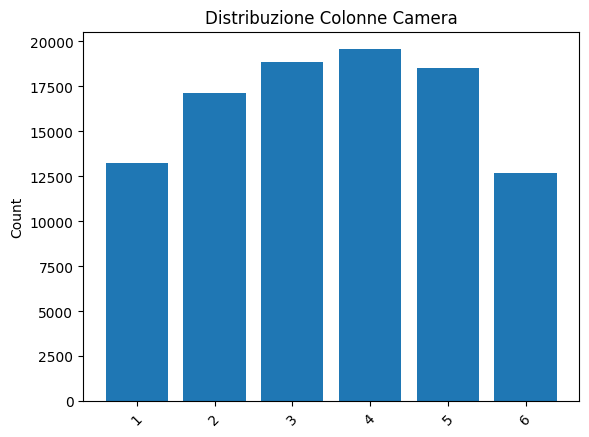

In [40]:
counts_camcol = df["cam_col"].value_counts()

plt.bar(counts_camcol.index, counts_camcol.values)

plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Distribuzione Colonne Camera")
plt.savefig("../reports/figures/camcol_distr.png", dpi=200)
plt.show()

le colonne centrali hanno raccolto il maggior numero di records. In generale questa feature non è una variabile fisica e porta informazioni su eventuali piccoli bias strumentali. Elimineremo questa variabile dal dataset.

### field_ID
Questa variabile identifica il campo di osservazione del rilevamento astronomico, ovvero una porzione specifica di cielo acquisita durante una scansione

In [41]:
print(f"Numero di campi osservati nel dataset: {df['field_ID'].nunique()}")

Numero di campi osservati nel dataset: 856


Il dataset contiene 856 campi di osservazione distinti su 100k osservazioni, il che indica una forte partizione spaziale dei dati.

Questa caratteristica codifica il contesto spaziale e osservativo piuttosto che proprietà astrofisiche intrinseche. Diverse regioni del cielo possono naturalmente contenere proporzioni diverse di stelle, galassie e quasar. Di conseguenza, la suddivisione casuale del dataset in set di training e di test può introdurre una dispersione spaziale, poiché campioni provenienti dallo stesso campo di osservazione potrebbero comparire in entrambi i sottoinsiemi.

Per mitigare questo problema, si dovrebbero preferire strategie di suddivisione di gruppo come `GroupShuffleSplit`, utilizzando `field_ID` come variabile di raggruppamento.

In [42]:
chi2, p, _, _ = chi2_contingency(pd.crosstab(df["field_ID"], df["class"]))
print(f"chi^2: {chi2}")
print(f"p-value: {p}")

chi^2: 2448.6107953524265
p-value: 2.648894064791351e-29


Il test del chi-quadrato rifiuta l'ipotesi di indipendenza tra `field_ID` e `class`, indicando che la distribuzione spaziale delle classi di oggetti non è uniforme nelle regioni di cielo osservate.

### spec_obj_ID
Questa variabile identifica uno specifico spettro acquisito, ovvero una singola misura spettroscopica prodotta in una certa osservazione

In [43]:
print(f"Numero univoco di oggetti acquisiti: {df["spec_obj_ID"].nunique()}")

Numero univoco di oggetti acquisiti: 100000


Poiché la caratteristica presenta la massima cardinalità (un valore univoco per osservazione), si comporta come un puro identificatore piuttosto che come una variabile predittiva informativa. Pertanto, non è possibile eseguire alcuna analisi statistica significativa su questa caratteristica e verrà esclusa dall'addestramento del modello per evitare potenziali overfitting ed effetti di memorizzazione spuri.

### plate
Questa variabile identifica la piastra spettroscopica usata per acquisire gli spettri, infatti la camera SDSS osserva il cielo tramite piastre perforate, ed ognuno di esse punta ad una specifica regione dello spazio. Perciò questa variabile non contiene nessuna variabile fisica sugli oggetti osservati.

In [44]:
print(f"Numero di plate: {df["plate"].nunique()}")

Numero di plate: 6284


In [45]:
df["plate"].value_counts().describe()

count    6284.000000
mean       15.913431
std        12.319458
min         1.000000
25%         7.000000
50%        13.000000
75%        22.000000
max        98.000000
Name: count, dtype: float64

Il dataset contiene 6.284 lastre spettroscopiche distinte, con una media di circa 16 osservazioni per lastra. Ciò indica una forte struttura di raggruppamento delle osservazioni, in cui più oggetti condividono la stessa configurazione di acquisizione e la stessa regione di cielo. Di conseguenza, non si può presumere che le osservazioni siano completamente indipendenti e identicamente distribuite (IID).

Sebbene la variabile `plate` rifletta la struttura di raggruppamento delle osservazioni del sondaggio SDSS, la caratteristica `field_ID` fornisce una partizione spaziale del cielo più significativa dal punto di vista fisico. Poiché le osservazioni vicine possono condividere caratteristiche astrofisiche e osservative, si preferisce una suddivisione in gruppi basata su `field_ID` per ridurre la dispersione spaziale e valutare meglio le prestazioni di generalizzazione.

Di conseguenza, la variabile `plate` viene esclusa dal set di caratteristiche finale e trattata solo come una variabile di metadati osservativi esplorata durante l'analisi esplorativa dei dati (EDA).

### fiber_ID
Questa variabile indica la fibra ottica specifica che ha raccolto la luce dell’oggetto sul piano focale del telescopio, osserviamo il loro numero

In [46]:
print(f"Numero di fibre ottiche del telescopio: {df["fiber_ID"].nunique()}")

Numero di fibre ottiche del telescopio: 1000


Questa features verrà tolta dall'analisi poiché non introduce nessuna informazione fisica sugli oggetti astrofisici.

## Variabili Temporali
### MJD
Questa varaibile (Modified Julian Date) rappresenta il momento temporale in cui l'osservazione SDSS è stata effettuata

In [47]:
df["MJD"].describe()

count    100000.000000
mean      55588.647500
std        1808.484233
min       51608.000000
25%       54234.000000
50%       55868.500000
75%       56777.000000
max       58932.000000
Name: MJD, dtype: float64

osservazioni distribuite su un arco temporale abbastanza ampio

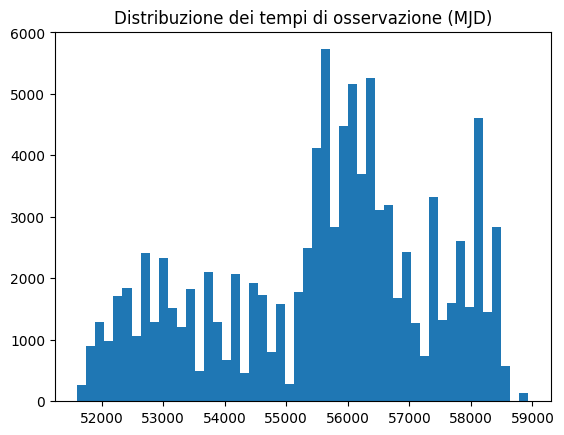

In [48]:
plt.hist(df["MJD"], bins=50)
plt.title("Distribuzione dei tempi di osservazione (MJD)")
plt.show()

sono presenti picchi di osservazione un paio di picchi di osservazioni in $~56000$ e $~58000$. Vediamo la distribuzione per classe

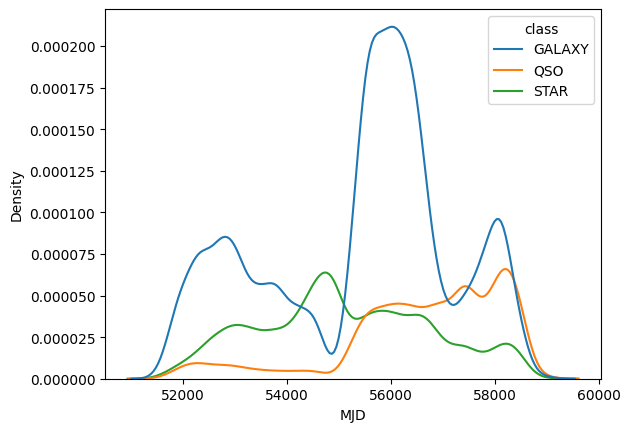

In [49]:
sns.kdeplot(data=df, x="MJD", hue="class");

Nel range temporale tra circa $55000$ e $57000$ `MJD` si osserva una maggiore densità relativa di galassie rispetto ad altri intervalli temporali. Le quasar risultano invece più concentrate in un intervallo leggermente più esteso (circa $55000–58000$ `MJD`), suggerendo una possibile dipendenza tra il periodo osservativo e la distribuzione delle classi. Le stelle appaiono invece distribuite in modo più uniforme lungo l’intero intervallo temporale.

Tuttavia, tali pattern potrebbero riflettere la strategia osservativa della survey piuttosto che una reale evoluzione temporale delle popolazioni astrofisiche, e devono quindi essere interpretati come potenziali bias di campionamento.

Per questo motivo, `MJD` viene trattato come metadato osservativo ed **escluso** dal set di caratteristiche finale per prevenire distorsioni temporali e migliorare la generalizzazione del modello.

## Variabili numeriche
### alpha & delta
La variabile `alpha` è l'**ascensione retta**, cioè una coordinata angolare nel cielo che misura la proporzione "orizzontale" dell'oggetto sulla sfera celeste e varia tra 0 e 360 gradi.

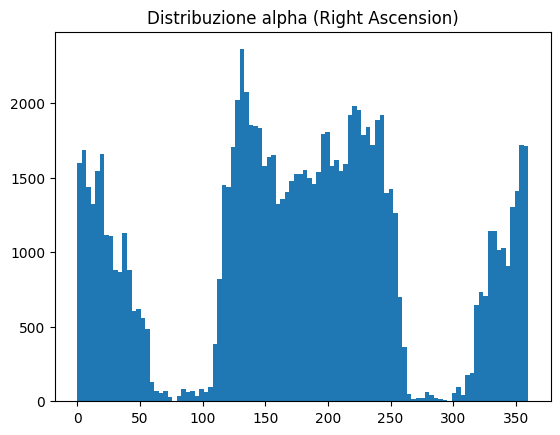

In [50]:
plt.hist(df["alpha"], bins=100)
plt.title("Distribuzione alpha (Right Ascension)")
plt.show()

il campione non è stato ottenuto osservando il cielo uniformemente, alcune regioni sono state campionate molto di più di altre. Osservo se le classi variano al variare di `alpha`

<Axes: xlabel='alpha', ylabel='Density'>

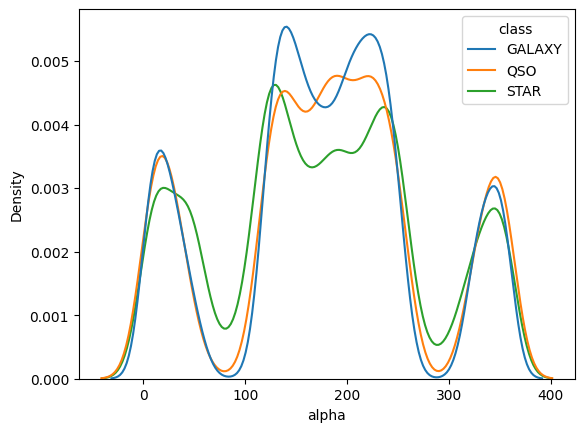

In [51]:
sns.kdeplot(data=df, x="alpha", hue="class", common_norm=False)

le distribuzioni sono relativamente sovrapponibili, ma la classe `STAR` sembra più presente vicino a $~100°$ e $~300°$ e leggermente meno nei picchi. Voglio valutare ora la relazione di questa variabile con la variabile `delta`, la seconda coordinata angolare celeste chiamata anche declination, assieme queste due variaabili fanno *longitudine* e *latitudine*

<Axes: xlabel='alpha', ylabel='delta'>

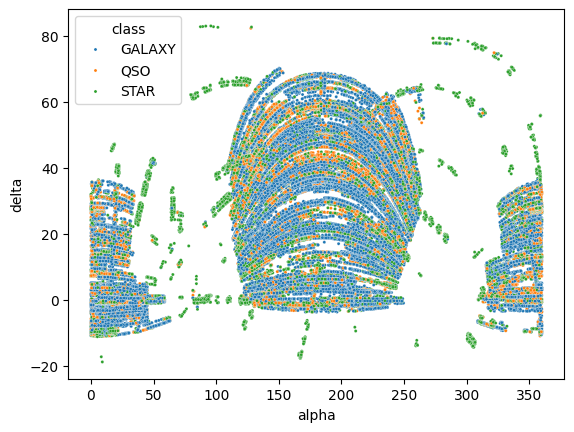

In [52]:
sns.scatterplot(data=df, x="alpha", y="delta", hue="class", s=5)

La distribuzione congiunta di `alfa` e `delta` rivela distinte strutture osservative ad arco corrispondenti alla geometria di scansione del rilevamento astronomico. Diversi archi appaiono dominati da una singola classe, indicando una forte eterogeneità spaziale nella distribuzione di stelle, galassie e quasar nelle regioni di cielo osservate. Ciò suggerisce la presenza di un bias osservativo spaziale, che potrebbe gonfiare artificialmente le prestazioni del modello in caso di suddivisioni casuali tra set di addestramento e di test.

L'analisi di `alfa` e `delta` rivela forti strutture spaziali associate alla geometria osservativa del sondaggio. Diverse regioni del cielo appaiono dominate da specifiche classi di oggetti, indicando una significativa eterogeneità spaziale e un potenziale bias osservativo.

Sebbene queste variabili contengano informazioni predittive, non rappresentano proprietà fisiche intrinseche degli oggetti osservati. Piuttosto, codificano informazioni posizionali e dipendenti dal sondaggio che potrebbero indurre il modello a sfruttare scorciatoie spaziali anziché caratteristiche astrofisiche.

Per questo motivo, `alfa` e `delta` non saranno inclusi nel set finale di caratteristiche predittive.

### u
Questa variabile misura l'intensità luminosa nella banda degli *ultravioletti* del sistema fotometrico. Quindi misura quanta radiazione ultravioletta emette/riflette un oggetto e perciò contiene informazioni come: temperatura, composizione, attività stellare, formazione stellare e fenomeni energetici dell'oggetto. 

In [53]:
df["u"].describe()

count    100000.000000
mean         21.980468
std          31.769291
min       -9999.000000
25%          20.352353
50%          22.179135
75%          23.687440
max          32.781390
Name: u, dtype: float64

La caratteristica `u` contiene valori non validi codificati come $-9999$, che probabilmente rappresentano misurazioni mancanti o non osservate. Poiché questi valori non hanno un significato fisico e distorcono significativamente le statistiche di distribuzione, vengono trattati come dati mancanti e gestiti in modo appropriato prima di ulteriori analisi.

In [54]:
(df["u"] == -9999).sum()

np.int64(1)

c'è un singolo valore mancante codificato come $-9999$, rendiamo coerente l'analisi per non distorcere distribuzione e grafici:

In [55]:
df["u"] = df["u"].replace(-9999, np.nan)

vediamo la distribuzione della variabile 

count    99999.000000
mean        22.080679
std          2.251068
min         10.996230
25%         20.352410
50%         22.179140
75%         23.687480
max         32.781390
Name: u, dtype: float64


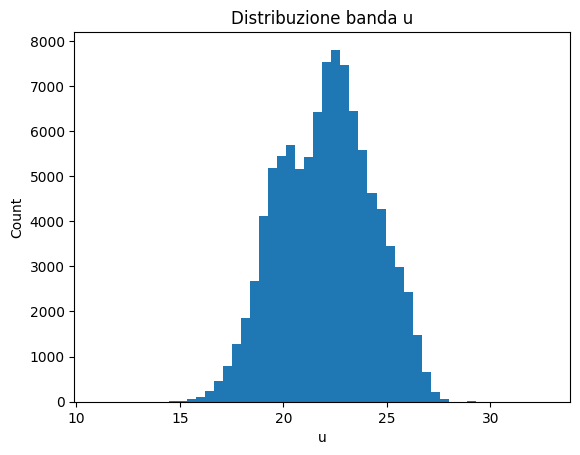

In [56]:
print(df["u"].describe())

plt.hist(df["u"], bins=50)
plt.title("Distribuzione banda u")
plt.xlabel("u")
plt.ylabel("Count")
plt.show()

In [57]:
print(f"Skewness: {skew(df["u"].dropna())}")
print(f"Kurtosis: {kurtosis(df["u"].dropna())}")

Skewness: -0.07029709633785107
Kurtosis: -0.5390726144797897


distribuzione quasi perfettamente simmetrica e con leggera platykurtiche, non sembrano esserci patologie da dover correggere.

Osserviamo ora le distribuzioni delle singole classi

e la distribuzione delle singole classi

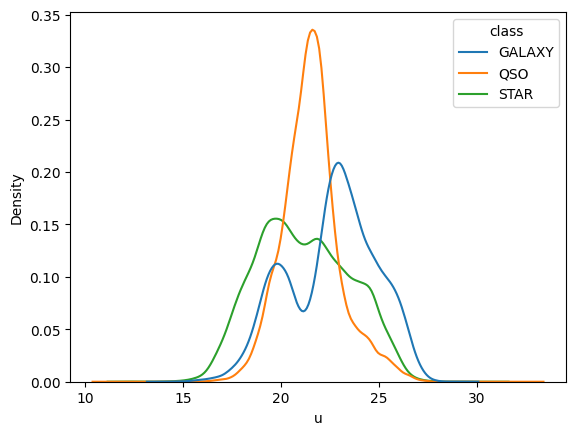

In [58]:
sns.kdeplot(data=df, x="u", hue="class", common_norm=False);

La banda `u` mostra una forte struttura condizionale di classe, indicando che veicola informazioni discriminanti per il compito di classificazione. Tuttavia, le distribuzioni di classe presentano forme diverse, suggerendo popolazioni fisiche sottostanti eterogenee. In particolare si osserva che:
- QSO: Picco netto di emissione UV
- GALAXY: Popolazione bimodale 
- STAR: distribuzione più continua

queste sono informazioni fisiche importantissime. Osserviamo la skewness e kurtosis per `u`

### g
E un'altra banda fotometrica del sistema SDSS e in particolare rappresenta la *green band*, cioè miusra la luminosità dell'oggetto astrofisico nella regione dello spettro corrispondente alla luce verde. Facciamo osservazioni analoghe ad `u`

In [59]:
print(df["g"].describe())
print(f"Numero di valori mancanti: {(df["g"] == -9999).sum()}")

count    100000.000000
mean         20.531387
std          31.750292
min       -9999.000000
25%          18.965230
50%          21.099835
75%          22.123767
max          31.602240
Name: g, dtype: float64
Numero di valori mancanti: 1


anche qui c'è solo un valore mancante, sostituiamo con `NaN`

In [60]:
df["g"] = df["g"].replace(-9999, np.nan)

osserviamo la distribuzione della variabile

count    99999.000000
mean        20.631583
std          2.037384
min         10.498200
25%         18.965240
50%         21.099930
75%         22.123775
max         31.602240
Name: g, dtype: float64


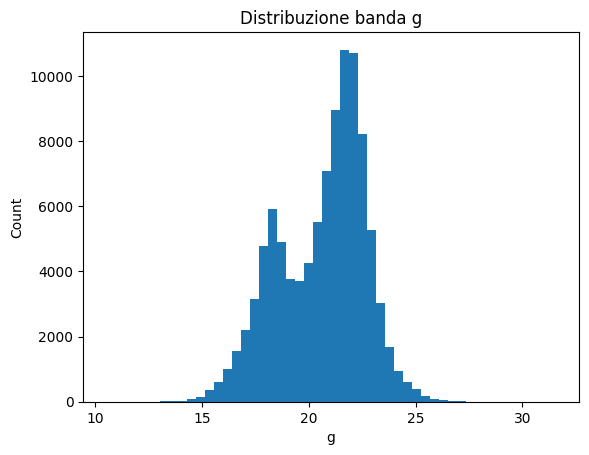

In [61]:
print(df["g"].describe())

plt.hist(df["g"], bins=50)
plt.title("Distribuzione banda g")
plt.xlabel("g")
plt.ylabel("Count")
plt.show()

In [62]:
print(f"Skewness: {skew(df["g"].dropna())}")
print(f"Kurtosis: {kurtosis(df["g"].dropna())}")

Skewness: -0.42803083988361024
Kurtosis: -0.37076294270309607


distribuzione quasi simmetrica (leggermente sposta sui valori grandi) e con leggermente platykurtiche. Non sembrano esserci patologie da correggere. 

Osserviamo ora la distribuzioni delle singole classi

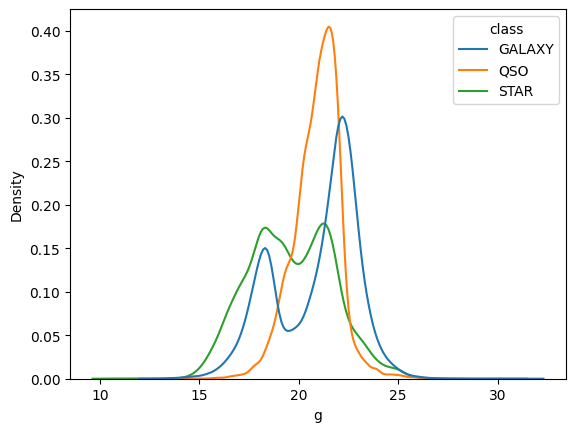

In [63]:
sns.kdeplot(data=df, x="g", hue="class", common_norm=False);

Andamento molto simile a quanto visto per la badna `u`.

### 

### r
Analogamente alla banda `g`, questa varaibile rappresenta la *red band*, misurando la luminosita dell'oggetto astrofisico nella regione dello spettro corrispondente al rosso

In [64]:
df["g"].describe()

count    99999.000000
mean        20.631583
std          2.037384
min         10.498200
25%         18.965240
50%         21.099930
75%         22.123775
max         31.602240
Name: g, dtype: float64

Non sono presenti valori tipici di data missing ($-9999$) per cui osserviamo subito la distribuzione

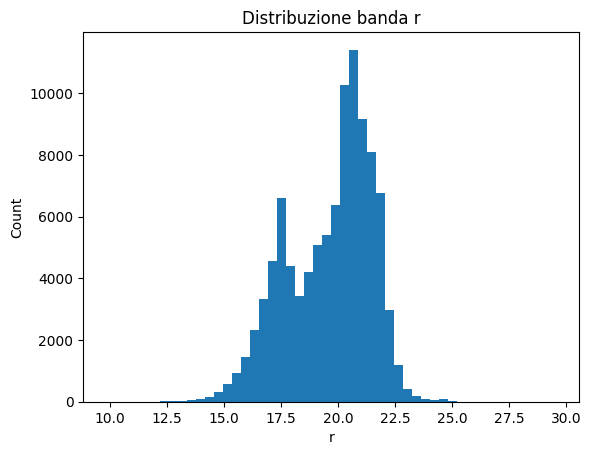

In [65]:
plt.hist(bins=50, x=df["r"])
plt.title("Distribuzione banda r")
plt.xlabel("r")
plt.ylabel("Count")
plt.show()

In [66]:
print(f"Skewness: {skew(df["r"].dropna())}")
print(f"Kurtosis: {kurtosis(df["r"].dropna())}")

Skewness: -0.5078508144253497
Kurtosis: -0.37619875532436


distribuzione moderatamente asimmetrica (ma non in modo preoccupante) e con una leggera platykurtiche, anche qui non sembrano essere necessario curare alcuna patologia.

Osserviamo le distribuzioni delle classi

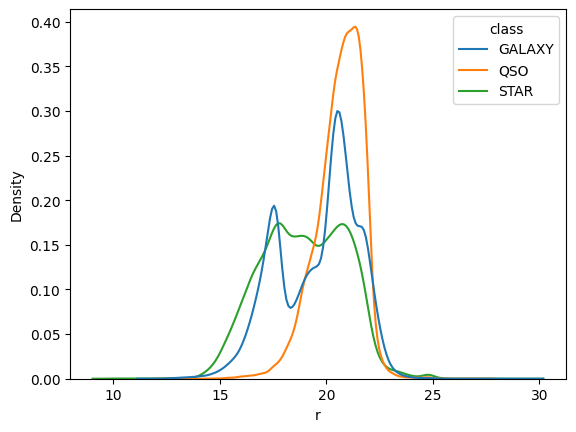

In [67]:
sns.kdeplot(data=df, x="r", hue="class", common_norm=False);

Anche qui solita distribuzione fortemente piccata per le Quasar, a doppio picco per le Galassie, mentre più distribuzione più "normale" per la Star.

### i
Questa variabile rappresenta la banda fotometrica **Near-Infrared** (vicino infrarosso) del sistema SDSS, quindi analizza la luminosità dell'oggetto astrofisico in una regione dello spettro meno energetico e più "fredda" rispetto alle variabili `u`, `g`, `r`.

In [68]:
df["i"].describe()

count    100000.000000
mean         19.084854
std           1.757895
min           9.469903
25%          17.732285
50%          19.405145
75%          20.396495
max          32.141470
Name: i, dtype: float64

non sono presenti missing value. Osserviamo la distribuzione globale

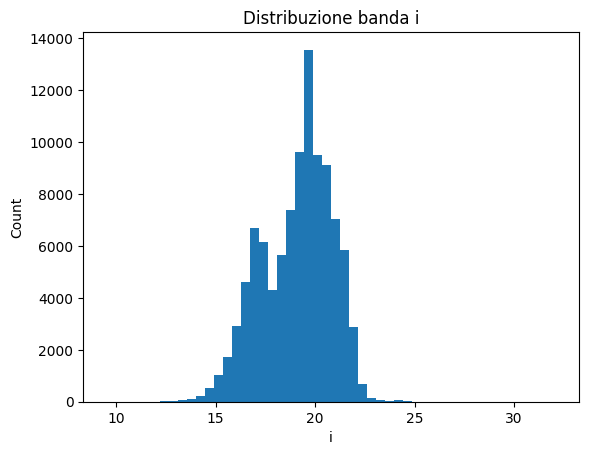

In [69]:
plt.hist(df["i"], bins=50)
plt.title("Distribuzione banda i")
plt.xlabel("i")
plt.ylabel("Count")
plt.show()

In [70]:
print(f"skewness: {skew(df["i"].dropna())}")
print(f"Kurtosis: {kurtosis(df["i"].dropna())}")

skewness: -0.40416067714144
Kurtosis: -0.23489272050987697


anche per questo banda spettrale non risultano esserci patologie, c`è una leggera asimmetria e bradikurtia non rendendo necessario alcuna correzione.

Osserviamo la distribuzione per le singole classi

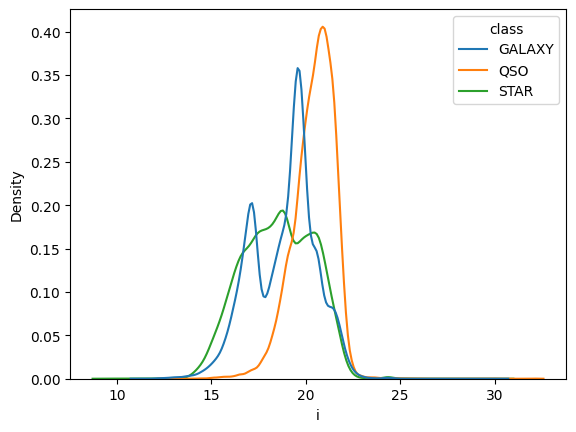

In [71]:
sns.kdeplot(data=df, x="i", hue="class", common_norm=False);

anche per questa banda le distribuzioni sono simili alle distribuzioni delle bande precedenti.

### z 
Questa variabile rappresenta la banda fotometrica **Infrared** del sistema SDSS

In [72]:
df["z"].describe()

count    100000.000000
mean         18.668810
std          31.728152
min       -9999.000000
25%          17.460677
50%          19.004595
75%          19.921120
max          29.383740
Name: z, dtype: float64

come per degli altri canali sono presenti missing value, rimuoviamoli

In [73]:
df["z"] = df["z"].replace(-9999, np.nan)

Osserviamo la distribuzione 

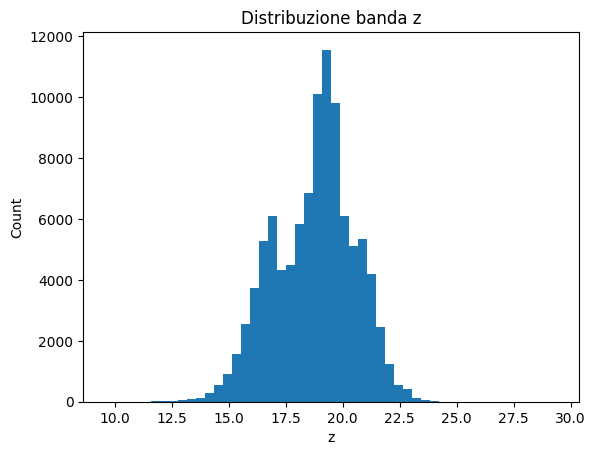

In [74]:
plt.hist(x=df["z"], bins=50)
plt.xlabel("z")
plt.ylabel("Count")
plt.title("Distribuzione banda z")
plt.show()

In [75]:
print(f"skewness: {skew(df["z"].dropna())}")
print(f"Kurtosis: {kurtosis(df["z"].dropna())}")

skewness: -0.25681798783933685
Kurtosis: -0.21005248649000086


anche per questa banda la distribuzione non è patologica e non richede alcuna trattazione al riguardo.

Osserviamo le distribuzioni per le singole classi

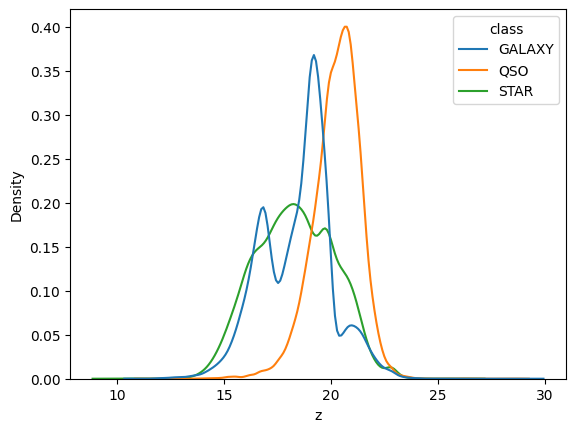

In [76]:
sns.kdeplot(data=df, x="z", hue="class", common_norm=False);

Andamenti molti simili delle bande precedenti.

### Matrice di correlazione u, g, r, i, z (+ redfshift)
Osserviamo la matrice di correlazione tra queste 5 bande (più il `redshift` che ci sarà utile per dopo)

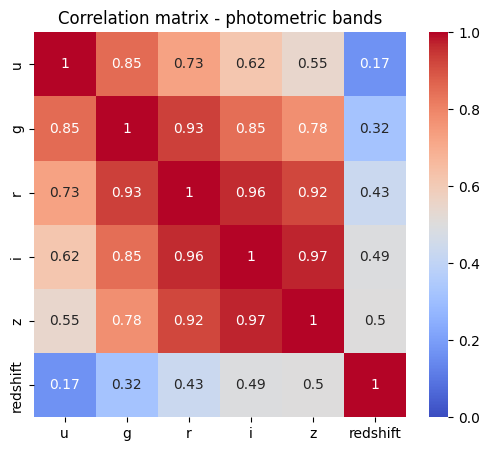

In [101]:
bands = ["u", "g", "r", "i", "z", "redshift"]

corr = df[bands].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation matrix - photometric bands")
plt.show()

le bande non sono feature indipendenti, ma campioni ordinati di una funzione spettrale continua, per cui si osserva un'altissima correlazione.

Facciamo ora un scatterplot tra tutte le bande

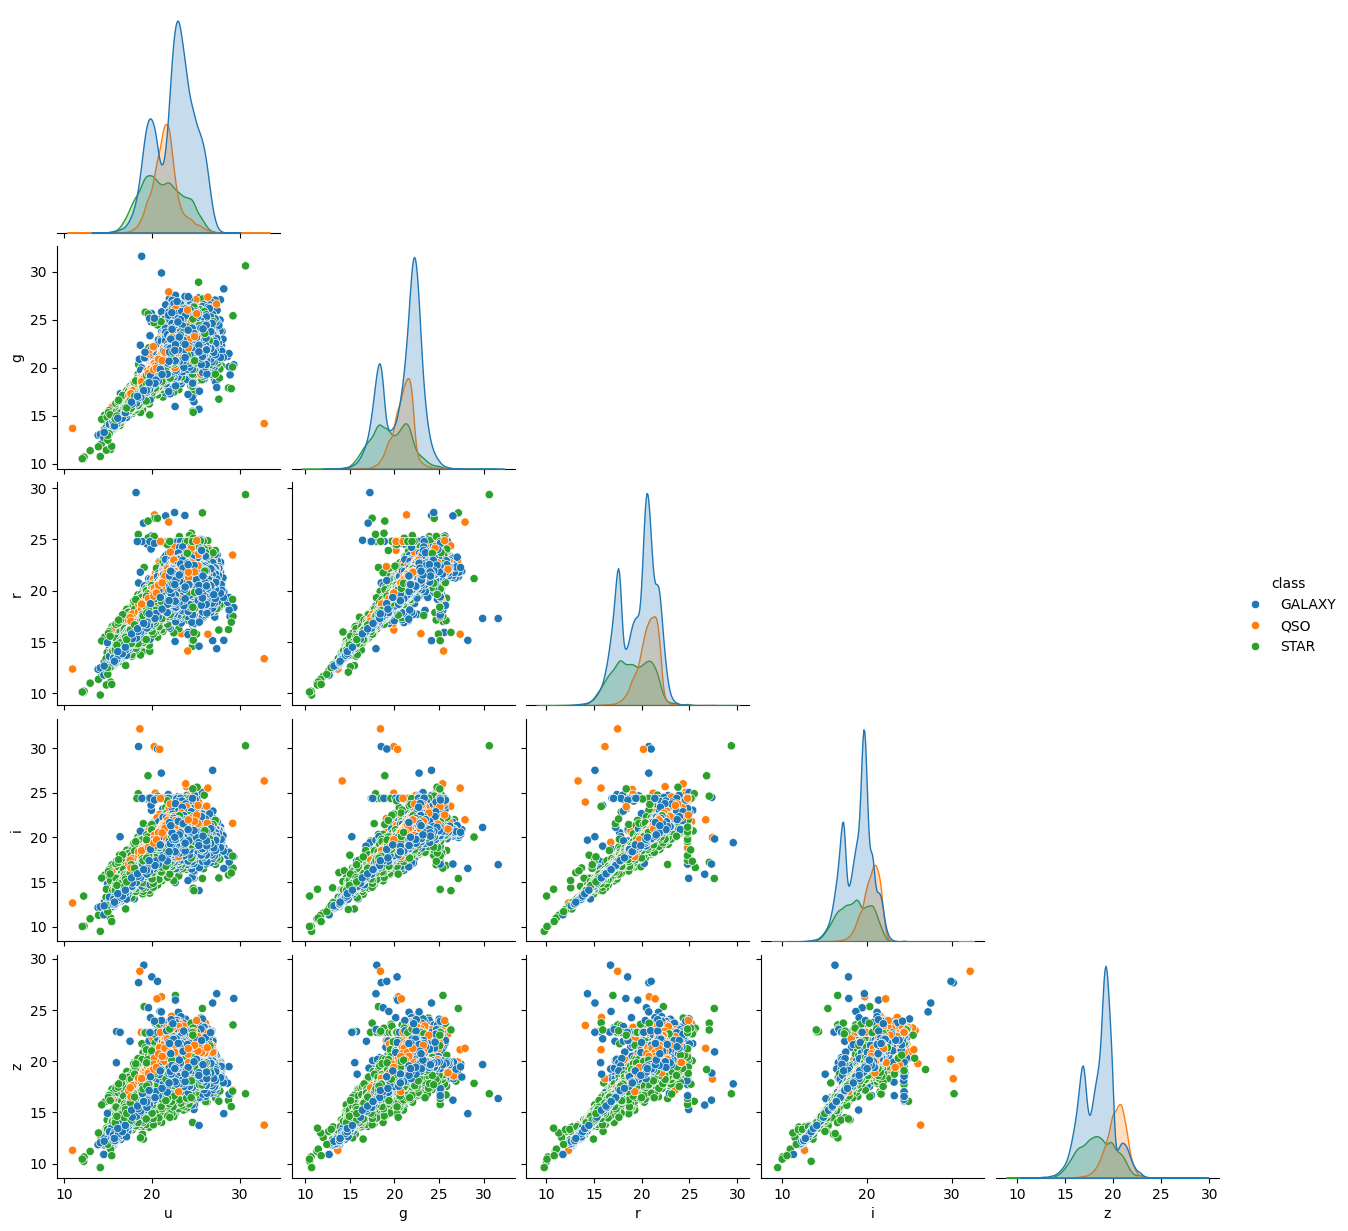

In [78]:
sns.pairplot(df[bands + ["class"]], hue="class", corner=True);

si osserva, su molti degli scatterplot, un andamento lineare crescente per le classe `STAR` e `GALAXY`, ne decuciamo che le popolazioni sono piu "coerenti" anche se `STAR` ha una dispersione leggermente maggiore. Invece per la classe `QSO` si osservano delle distribuzioni che non seguono rette ed occupano un'area più grande, quindi esse rompono la relazione lineare tra bande.

Inoltre si osservano che le relazioni a coppie tra le bande fotometriche rivelano una struttura non lineare "a freccia" coerente, condivisa da tutte le classi (stelle, galassie, quasar). Ciò indica che la geometria osservata è determinata principalmente dalla struttura di correlazione intrinseca della distribuzione spettrale di energia, piuttosto che da effetti specifici di ciascuna classe. La presenza di una curvatura in questa varietà suggerisce l'esistenza di regimi non lineari nella mappatura tra le bande fotometriche, probabilmente associati a transizioni osservative o fisiche nelle sorgenti sottostanti.

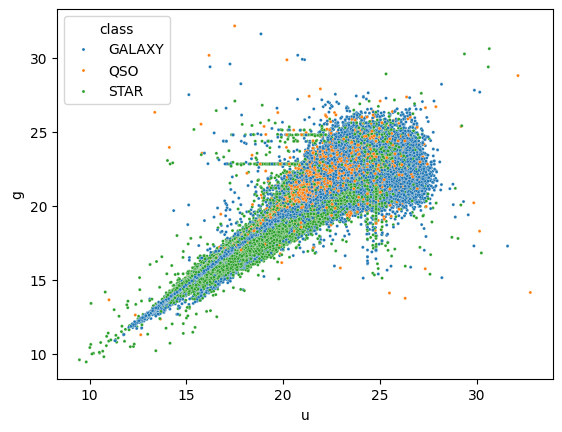

In [79]:
sns.scatterplot(data=df, x="u", y="g", hue="class", s=5)
sns.scatterplot(data=df, x="g", y="r", hue="class", s=5, legend=False)
sns.scatterplot(data=df, x="r", y="i", hue="class", s=5, legend=False)
sns.scatterplot(data=df, x="i", y="z", hue="class", s=5, legend=False);

I diagrammi di dispersione a coppie tra le bande fotometriche mostrano una struttura fortemente correlata, caratterizzata da una varietà approssimativamente lineare a basse magnitudini, seguita da una regione di dispersione non lineare attorno a valori di magnitudine più elevati. Questa transizione riflette probabilmente una combinazione di limiti osservativi (degrado del rapporto segnale/rumore) e la miscelazione di popolazioni astrofisiche a regimi di flusso più deboli. Ulteriori caratteristiche geometriche, come le strutture "a freccia", suggeriscono la presenza di distorsioni non lineari ed effetti di discretizzazione introdotti dalla pipeline fotometrica.

Studiamo ora meglio la multicollinearità e vediamo tramite PCA, quante sono le componenti che spiegano la maggior parte della varianza

In [80]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_clean = df.dropna(subset=["u", "g", "r", "i", "z"])

X = df_clean[["u", "g", "r", "i", "z"]]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.85633568, 0.11770226, 0.01859073, 0.00453492, 0.00283642])

L'analisi delle componenti principali (PCA) applicata alle bande fotometriche rivela che l'85,6% della varianza è catturato dalla prima componente principale e il 97,4% dalle prime due componenti. Ciò indica che lo spazio fotometrico a 5 dimensioni giace effettivamente su una varietà a bassa dimensionalità, coerentemente con l'interpretazione secondo cui le bande rappresentano campioni correlati di una distribuzione continua di energia spettrale. La dimensionalità intrinseca del sistema è quindi approssimativamente due, corrispondente alla luminosità complessiva e alla pendenza spettrale.

Osserviamo la matrice di correlazione di queste nuove feature:

### redshift
Questa variabile misura lo spostamento verso lunghezze d’onda maggiori della luce emessa da un oggetto astronomico, ed è causato principalmente dall’espansione dell’Universo, per questo motiva ha una forte valenza fisica ed è direttamente legata alla distanza cosmologica

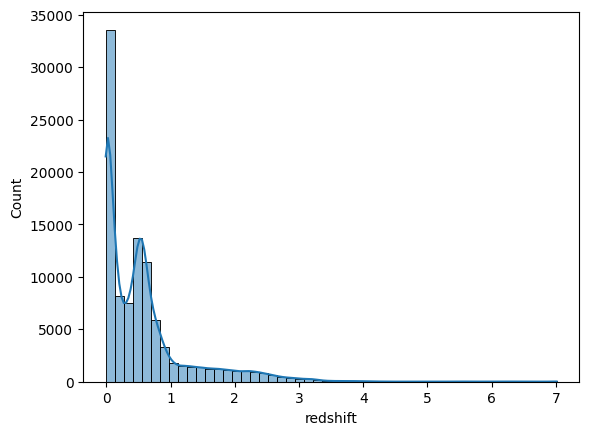

In [81]:
sns.histplot(df["redshift"], bins=50, kde=True);

La distribuzione del redshift è strettamente positiva e fortemente asimmetrica, con un picco dominante vicino allo zero ($z ≈ 0$), corrispondente principalmente a oggetti stellari e galattici vicini. Si osserva una concentrazione secondaria attorno a valori intermedi ($z ≈ 0,5–0,7$), con circa $15.000$ occorrenze, probabilmente associate a galassie e quasar a redshift più elevato. La distribuzione decade poi rapidamente, formando una lunga coda che si estende fino a $z ≈ 7$, caratteristica di rari quasar ad alto redshift.

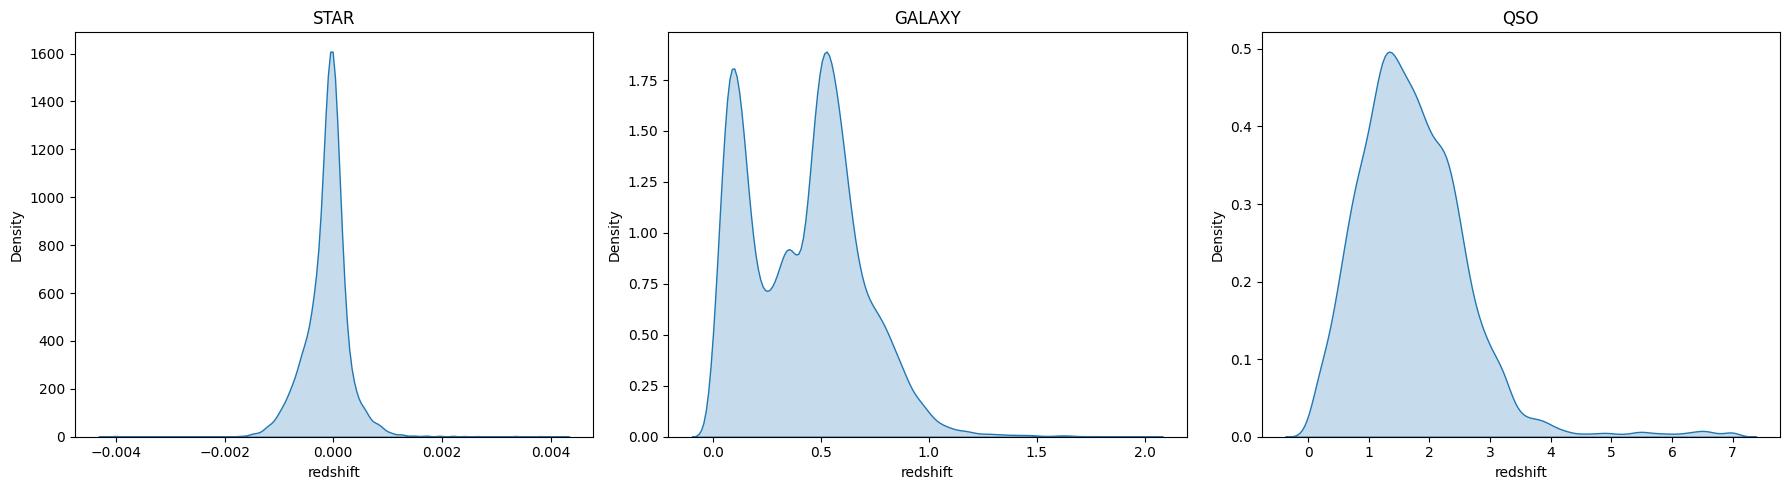

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(df[df["class"] == "STAR"]["redshift"], ax=axes[0], fill=True)
axes[0].set_title("STAR")

sns.kdeplot(df[df["class"] == "GALAXY"]["redshift"], ax=axes[1], fill=True)
axes[1].set_title("GALAXY")

sns.kdeplot(df[df["class"] == "QSO"]["redshift"], ax=axes[2], fill=True)
axes[2].set_title("QSO")

plt.tight_layout()
plt.show()

Le distribuzioni di redshift rivelano forti strutture dipendenti dalla classe. Le stelle sono concentrate intorno a $z ≈ 0$, in accordo con la loro natura locale. Le galassie mostrano una distribuzione bimodale con picchi intorno a $z ≈ 0,1$ e $z ≈ 0,6$, seguiti da una coda decrescente verso redshift più elevati. I quasar mostrano una distribuzione unimodale centrata intorno a $z ≈ 1,5$ con una lunga coda ad alto redshift che si estende oltre $z ≈ 7$, riflettendo le loro distanze cosmologiche e gli effetti di selezione nelle indagini spettroscopiche.

Mi chiedo ora se la variabile `redshift` separa *bene* la classe dei quasar tramite la metrica **ROC-AUC**, che misura la capacità discriminativa di una singola feature o modello semplice

In [83]:
from sklearn.metrics import roc_auc_score

df_binary = df.copy()
df_binary["is_qso"] = (df["class"] == "QSO").astype(int)

print(f"ROC-AUC quasar: {round(roc_auc_score(df_binary["is_qso"], df["redshift"]),3)}")

ROC-AUC quasar: 0.962


otteniamo uno score davvero elevato ottenendo che la variabile `redshift` ha un forte potere discriminatorio per la classe Quasar.

A complemento dell'analisi univariata basata su ROC-AUC, viene addestrato un modello multivariato non lineare (classificatore Random Forest) al fine di valutare l'importanza relativa di ciascuna caratteristica quando tutti i predittori vengono considerati congiuntamente. A differenza dell'analisi ROC-AUC, che valuta il potere discriminante di una singola variabile in isolamento, il Random Forest cattura le interazioni tra le caratteristiche e la ridondanza tra le bande fotometriche

In [84]:
from sklearn.ensemble import RandomForestClassifier

X = df[["u", "g", "r", "i", "z", "redshift"]]
y = df["class"]

model = RandomForestClassifier()
model.fit(X, y)

pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

redshift    0.676663
z           0.101544
g           0.073641
u           0.056767
i           0.054690
r           0.036695
dtype: float64

L'analisi dell'importanza delle caratteristiche del classificatore Random Forest indica che il redshift è il predittore dominante della classe dell'oggetto, rappresentando circa il $65\%$ dell'importanza totale. Le bande fotometriche (`u, g, r, i, z`) contribuiscono collettivamente al restante potere predittivo, riflettendo la loro elevata correlazione reciproca e ridondanza. Ciò suggerisce che la maggior parte della separabilità nel dataset è determinata dalla distanza cosmologica (redshift), mentre le informazioni sul colore forniscono un affinamento aggiuntivo ma secondario.

### Feature Engineering: Indici di Colore
In astrofisica, le singole bande fotometriche (`u, g, r, i, z`) misurano la "luminosità totale" dell'oggetto in diverse regioni dello spettro. Tuttavia, come visto dalla PCA e dalla matrice di correlazione, queste misurazioni sono altamente correlate tra loro (multicollinearità): un oggetto intrinsecamente brillante (o molto vicino) apparirà semplicemente molto luminoso in tutte le bande.

Per isolare la **forma dello spettro** (che dipende fisicamente dalla temperatura superficiale, dalla composizione e dal tipo di oggetto) dall'effetto della **luminosità assoluta** (che dipende dalla distanza), gli astronomi calcolano i cosiddetti "indici di colore", ovvero le differenze di magnitudine tra bande adiacenti (es. $u-g$, $g-r$). 

Calcolando la differenza, il termine comune legato alla distanza e all'intensità assoluta si elide, lasciando un parametro intrinseco dell'oggetto. Creiamo queste nuove features:


In [95]:
# Calcolo degli indici di colore
df["u-g"] = df["u"] - df["g"]
df["g-r"] = df["g"] - df["r"]
df["r-i"] = df["r"] - df["i"]
df["i-z"] = df["i"] - df["z"]

color_cols = ["u-g", "g-r", "r-i", "i-z"]

Plottiamo la matrice di correlazione tra gli indici di colore e il `redshift`

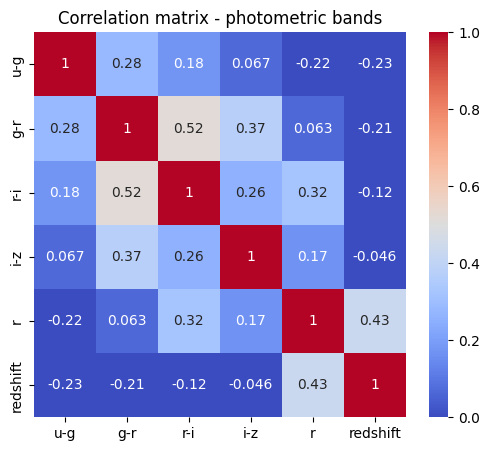

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["u-g", "g-r", "r-i", "i-z", "redshift"]].corr(), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation matrix - photometric bands")
plt.show()

Come notato dalla matrice di correlazione appena generata, la correlazione lineare tra gli indici di colore è drasticamente inferiore rispetto a quella tra le bande grezze, e anche la correlazione lineare con il redshift sembra diminuita.

Questo è in realtà un risultato estremamente positivo per i nostri modelli di Machine Learning, per due motivi fondamentali:

1. **Riduzione della Multicollinearità**: Avendo rimosso l'effetto della luminosità assoluta (il fattore di scala comune), abbiamo eliminato la ridondanza lineare. I colori catturano variazioni spettrali indipendenti (es. salti di emissione tipici di galassie o discontinuità di Balmer per le stelle).
2. **Relazioni Non-Lineari**: Il redshift scala l'intero spettro spostandolo verso lunghezze d'onda maggiori. Gli indici di colore catturano questi "spostamenti" come transizioni fortemente non-lineari. La correlazione di Pearson non riesce a catturare bene queste dinamiche complesse, ma un modello non lineare (come un Random Forest o Gradient Boosting) le sfrutterà in modo ottimale.

**Best Practice in Astronomia:** La prassi standard per la classificazione consiste nel fornire al modello gli **indici di colore** (per la forma spettrale) + **1 singola banda originale** (tipicamente la `r` o la `i`, che funge da "ancora" per la magnitudine assoluta) + il `redshift`. Se mantenessimo contemporaneamente tutte le bande originali e tutti i colori, reintrodurremmo una perfetta collinearità lineare (es.  `𝑢`=(`𝑢−𝑔`)+`𝑔`).

Per dimostrare il potere separatore dei colori, costruiamo un classico **Diagramma Colore-Colore**, molto utilizzato in astrofisica per classificare gli oggetti isolandoli in specifici domini di questo spazio 2D, senza dover ricorrere alla complessa spettroscopia.

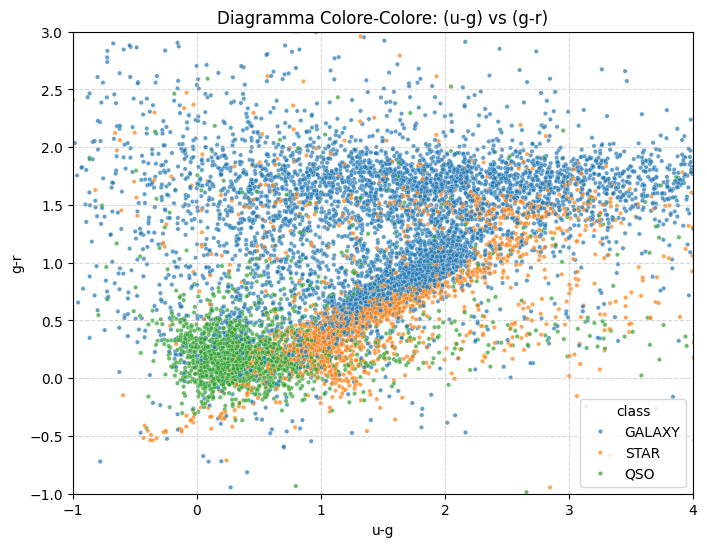

In [104]:
plt.figure(figsize=(8, 6))
# Usiamo un sample per non sovraffollare il grafico
sample_df = df.sample(10000, random_state=42)
sns.scatterplot(data=sample_df, x="u-g", y="g-r", hue="class", s=10, alpha=0.7)
plt.title("Diagramma Colore-Colore: (u-g) vs (g-r)")
plt.xlim(-1, 4)
plt.ylim(-1, 3)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Dal grafico sopra vediamo come le classi inizino a separarsi in domini specifici dello spazio dei colori (es. le Quasar tendono a separarsi dalla sequenza principale delle stelle).

Vediamo ora come cambia la **Feature Importance** se forniamo al Random Forest un mix ottimizzato: gli indici di colore per la forma spettrale, la banda `r` come indicatore di luminosità assoluta, e il `redshift`.

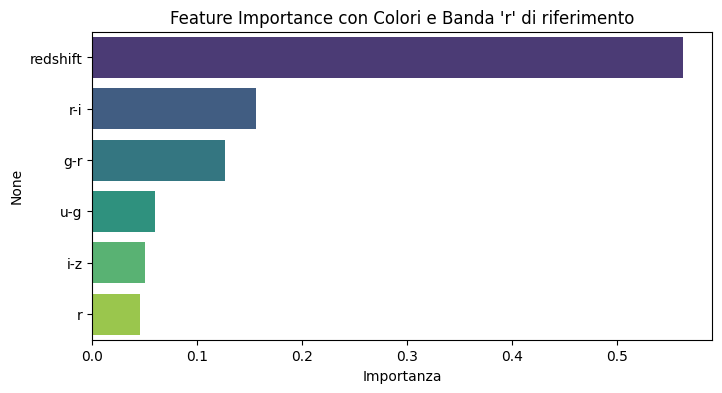

redshift    0.562235
r-i         0.155973
g-r         0.126082
u-g         0.059755
i-z         0.050057
r           0.045896
dtype: float64

In [105]:
from sklearn.ensemble import RandomForestClassifier

# Set ottimizzato: 1 banda di riferimento, 4 colori, 1 redshift
optimal_features = ["r", "u-g", "g-r", "r-i", "i-z", "redshift"]

X_opt = df.dropna(subset=optimal_features)[optimal_features]
y_opt = df.dropna(subset=optimal_features)["class"]

rf_model_opt = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_opt.fit(X_opt, y_opt)

importanza = pd.Series(rf_model_opt.feature_importances_, index=X_opt.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importanza.values, y=importanza.index, hue=importanza.index, legend=False, palette="viridis")
plt.title("Feature Importance con Colori e Banda 'r' di riferimento")
plt.xlabel("Importanza")
plt.show()

display(importanza)

Si osserva che:
- **Il `redshift` resta il discriminante principale**: Con circa il 56% di importanza, il `redshift` rimane essenziale, poiché traccia le enormi differenze di distanza cosmologica tra le Stelle (locali, $𝑧\simeq 0$ ), le Galassie (distanze intermedie) e le Quasar (estremamente lontane).
- **Il trionfo della forma spettrale (Colori)**: Gli indici di colore, in particolare `r-i` ($15\%$) e `g-r` ($12\%$), hanno catturato una forte fetta del potere predittivo. Essi descrivono la "firma termica e chimica" dell'oggetto, rivelandosi molto più discriminanti rispetto alle singole bande.
- **Il ruolo marginale della luminosità assoluta**: La banda `r` isolata (che abbiamo tenuto per rappresentare la magnitudine apparente/luminosità) risulta l'attributo meno importante (sotto il $5\%$). Questo conferma che per classificare la natura di un corpo celeste, sapere quanto brilla nel cielo conta molto meno rispetto a conoscerne lo spettro termico (colori) e la cinematica (redshift).

## Conclusioni EDA e Next Steps
L'analisi esplorativa ha rivelato importanti proprietà fisiche e bias osservativi intrinseci al dataset SDSS. In ottica di messa in produzione e costruzione di una pipeline di Machine Learning robusta e scalabile, ecco le azioni architetturali da implementare per ciascuna variabile:

### Variabile Target
* **`class`**: Variabile sbilanciata (Galaxy $\approx$ 59%, Star $\approx$ 22%, QSO $\approx$ 19%). 
  * *Azione MLOps*: Codificare tramite `LabelEncoder`. In fase di training, compensare lo sbilanciamento (es. `class_weight="balanced"`). In produzione, monitorare costantemente il *Target Drift*.

### Metadati Strumentali e Identificatori (Da Scartare)
Variabili che introducono rumore, memorizzazione o bias legati all'hardware del telescopio.
* **`obj_ID`, `spec_obj_ID`**: 
  * *Azione MLOps*: Scartare (Drop). Utilizzare solo per tracciamento/logging predizioni nel database MLOps.
* **`run_ID`, `rerun_ID`, `cam_col`, `plate`, `fiber_ID`**: 
  * *Azione MLOps*: Drop nella fase di Data Validation/Preprocessing per evitare che il modello impari scorciatoie strumentali.

### Variabili Spaziali e Temporali (Gestione Bias)
* **`field_ID`**: 
  * *Azione MLOps*: Drop in fase di inferenza. In fase di training/validation, utilizzarla **obbligatoriamente** come chiave per il `GroupShuffleSplit`, garantendo l'isolamento spaziale tra Train e Test.
* **`MJD`** (Data osservazione): 
  * *Azione MLOps*: Drop per evitare data leakage temporale.
* **`alpha`, `delta`** (Coordinate Celesti): 
  * *Azione MLOps*: Drop. Il modello deve essere invariante rispetto alla regione di cielo puntata.

### Features Fisiche e Feature Engineering (Input del Modello)
Il core predittivo del modello.
* **`u`, `g`, `i`, `z`** (Bande fotometriche):
  * *Azione MLOps*: Sostituire eventuali `-9999` con `NaN` e droppare le righe/imputarle. Utilizzare queste colonne *esclusivamente* per calcolare gli indici di colore, per poi **eliminarle** al fine di ridurre la multicollinearità.
* **`u-g`, `g-r`, `r-i`, `i-z`** (Nuove feature derivate):
  * *Azione MLOps*: Includere il calcolo di queste differenze in un *Custom Transformer* della Pipeline di Scikit-Learn (o equivalente), per garantirne la riproducibilità in real-time durante l'inferenza.
* **`r`** (Banda di riferimento assoluto):
  * *Azione MLOps*: Mantenere nel dataset finale come rappresentante della luminosità/magnitudine apparente totale.
* **`redshift`** (Distanza cosmologica/Cinematica):
  * *Azione MLOps*: Mantenere invariato. Essendo la feature predittiva dominante (~56% di importanza), sarà cruciale impostare rigidi allarmi di *Data Drift* (es. test di Kolmogorov-Smirnov) su questa variabile nel sistema di Model Monitoring in produzione.

In [112]:
df["MJD"].tail()

99995    57749
99996    56934
99997    54535
99998    56368
99999    57104
Name: MJD, dtype: int64

In [115]:
df_ordered = df.sort_values(by="MJD", ascending=True)
df_ordered["MJD"].tail()

64545    58932
60794    58932
64546    58932
974      58932
66749    58932
Name: MJD, dtype: int64

In [119]:
df_ordered.iloc[-1:]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u-g,g-r,r-i,i-z
66749,1.237674e+18,130.658875,-1.553303,21.02673,20.85872,20.6084,20.50367,20.66768,6574,301,...,1.410194e+19,QSO,3.363294,12525,58932,167,0.16801,0.25032,0.10473,-0.16401


In [123]:
df_ordered.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u-g,g-r,r-i,i-z
12866,1.237651e+18,147.366840,0.968375,20.57743,18.60067,17.79560,17.34576,17.05482,1239,301,...,3.007145e+17,GALAXY,0.102337,267,51608,361,1.97676,0.80507,0.44984,0.29094
76291,1.237649e+18,148.526411,-0.971684,18.49726,17.37068,16.97899,16.84624,16.80118,756,301,...,3.006288e+17,STAR,0.000459,267,51608,49,1.12658,0.39169,0.13275,0.04506
62175,1.237649e+18,149.184901,0.242107,19.96493,18.18508,17.27958,16.87634,16.57329,756,301,...,3.007904e+17,GALAXY,0.086801,267,51608,637,1.77985,0.90550,0.40324,0.30305
60850,1.237649e+18,149.032392,0.288143,19.69001,18.45888,17.75000,17.33397,17.07845,756,301,...,3.007898e+17,GALAXY,0.126991,267,51608,635,1.23113,0.70888,0.41603,0.25552
5390,1.237651e+18,148.137883,0.984109,17.94048,15.85076,14.92413,14.48684,14.15116,1239,301,...,3.007621e+17,GALAXY,0.046764,267,51608,534,2.08972,0.92663,0.43729,0.33568


In [129]:
df_ordered["MJD"].iloc[-1]

np.int64(58932)

In [131]:
df["r-i"] = df["r"] - df["i"]
df["r-i"].head()

0    1.22928
1    1.41632
2    1.26119
3    1.10708
4    0.52036
Name: r-i, dtype: float64

In [144]:
if not all(x in df.columns for x in ["u", "g", "r", "i", "z"]):
    print("ci sono")

In [141]:
for x in ["u", "t", "g", "r", "i", "z"]:
    if x in df.columns:
        print(True)

True
True
True
True
True


In [148]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u-g,g-r,r-i,i-z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250


In [146]:
if not all(x in df.columns for x in ["u", "g", "r", "i"]):
    raise ValueError("Attenzione non sono state create le features di colore!")

In [157]:
df[df["u"] == -9999]

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79543,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


In [159]:
dati = {
    "Nome": ["Marco", "Giulia", "Luca", "Anna", "Antonio"],
    "Età": [28, 24, 31, 22, 22],
    "Città": ["Roma", "Milano", "Napoli", "Torino", "Roma"],
}
df = pd.DataFrame(dati)

In [160]:
df.head()

,Nome,Età,Città
0,Marco,28,Roma
1,Giulia,24,Milano
2,Luca,31,Napoli
3,Anna,22,Torino
4,Antonio,22,Roma


In [164]:
df_sub = df[df["Età"] == 22]
df_sub.head()

,Nome,Età,Città
3,Anna,22,Torino
4,Antonio,22,Roma


In [170]:
df_new = df.replace(22, 1)
df_new.head()

,Nome,Età,Città
0,Marco,28,Roma
1,Giulia,24,Milano
2,Luca,31,Napoli
3,Anna,1,Torino
4,Antonio,1,Roma


In [172]:
df.shape

(5, 3)

In [173]:
type(df)

pandas.DataFrame